In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from PIL import Image
import os

train_df = pd.read_csv('../data/train.csv')

print("Shape:", train_df.shape)
print("\nColumns:", train_df.columns.tolist())
print("\nFirst 5 rows:")
train_df.head()

Matplotlib is building the font cache; this may take a moment.


Shape: (21397, 2)

Columns: ['image_id', 'label']

First 5 rows:


,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [3]:
print("Current working directory:", os.getcwd())
print("\nContents of ../data/:")
print(os.listdir('../data'))

Current working directory: c:\cassava-leaf-disease-classification\notebooks

Contents of ../data/:
['1000015157.jpg', '1000201771.jpg', '100042118.jpg', '1000723321.jpg', '1000812911.jpg', '1000837476.jpg', '1000910826.jpg', '1001320321.jpg', '1001723730.jpg', '1001742395.jpg', '1001749118.jpg', '100204014.jpg', '1002088496.jpg', '1002255315.jpg', '1002394761.jpg', '1003218714.jpg', '1003298598.jpg', '1003442061.jpg', '1003888281.jpg', '1003987001.jpg', '1004105566.jpg', '1004163647.jpg', '1004389140.jpg', '1004672608.jpg', '100472565.jpg', '1004826518.jpg', '1004881261.jpg', '1005138819.jpg', '1005200906.jpg', '100533489.jpg', '100560400.jpg', '1005695738.jpg', '1005739807.jpg', '100609661.jpg', '1007196516.jpg', '1007246985.jpg', '100731318.jpg', '1007533812.jpg', '1007700625.jpg', '1007891044.jpg', '1008126487.jpg', '1008142548.jpg', '1008244905.jpg', '1008284502.jpg', '1008532311.jpg', '1009037539.jpg', '1009049118.jpg', '1009126931.jpg', '1009148537.jpg', '1009268848.jpg', '100932

In [9]:
image_files = os.listdir('../data/train_images')
print("Number of image files found:", len(image_files))
print("Sample filenames:", image_files[:5])


Number of image files found: 21397
Sample filenames: ['1000015157.jpg', '1000201771.jpg', '100042118.jpg', '1000723321.jpg', '1000812911.jpg']


In [8]:

print("Rows in train.csv:", len(train_df))
print("Image files found:", len(image_files))
print("Difference:", len(image_files) - len(train_df))

non_jpg = [f for f in image_files if not f.endswith('.jpg')]
print("\nNon-.jpg files found:", len(non_jpg))
print(non_jpg[:10])

print("\nUnique filenames:", len(set(image_files)))

Rows in train.csv: 21397
Image files found: 21397
Difference: 0

Non-.jpg files found: 0
[]

Unique filenames: 21397


In [7]:
with open('../data/label_num_to_disease_map.json') as f:
    label_map = json.load(f)

print("Label mapping:")
for k, v in label_map.items():
    print(f"  {k}: {v}")

train_df['disease_name'] = train_df['label'].astype(str).map(label_map)

print("\nClass distribution (counts):")
print(train_df['label'].value_counts().sort_index())

print("\nClass distribution (%):")
print(train_df['label'].value_counts(normalize=True).sort_index().mul(100).round(2))

Label mapping:
  0: Cassava Bacterial Blight (CBB)
  1: Cassava Brown Streak Disease (CBSD)
  2: Cassava Green Mottle (CGM)
  3: Cassava Mosaic Disease (CMD)
  4: Healthy

Class distribution (counts):
label
0     1087
1     2189
2     2386
3    13158
4     2577
Name: count, dtype: int64

Class distribution (%):
label
0     5.08
1    10.23
2    11.15
3    61.49
4    12.04
Name: proportion, dtype: float64


In [10]:
print("Contents of ../data/:")
print(os.listdir('../data'))

print("\nNon-.jpg files still inside train_images/ (should be empty now):")
all_files = os.listdir('../data/train_images')
non_jpg_in_images_folder = [f for f in all_files if not f.endswith('.jpg')]
print(non_jpg_in_images_folder)

print("\nImage count in train_images/ (should still be 21397):")
print(len(all_files) - len(non_jpg_in_images_folder) if non_jpg_in_images_folder else len(all_files))

Contents of ../data/:
['label_num_to_disease_map.json', 'train.csv', 'train_images']

Non-.jpg files still inside train_images/ (should be empty now):
[]

Image count in train_images/ (should still be 21397):
21397


C:\Users\hp\AppData\Local\Temp\ipykernel_14332\3369052362.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, palette=colors)


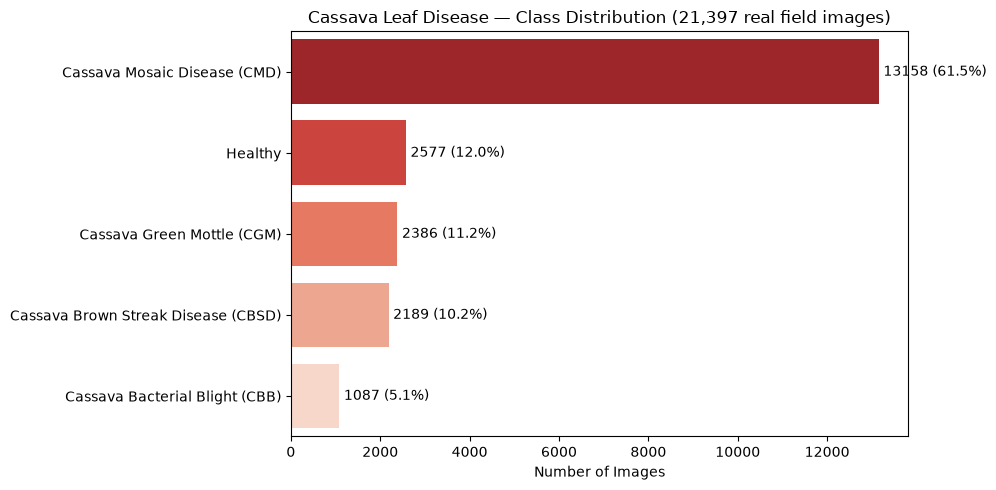

In [11]:
plt.figure(figsize=(10,5))
class_counts = train_df['disease_name'].value_counts()
colors = sns.color_palette('Reds_r', len(class_counts))
sns.barplot(x=class_counts.values, y=class_counts.index, palette=colors)
plt.title('Cassava Leaf Disease — Class Distribution (21,397 real field images)')
plt.xlabel('Number of Images')
plt.ylabel('')
for i, v in enumerate(class_counts.values):
    plt.text(v + 100, i, f'{v} ({v/len(train_df)*100:.1f}%)', va='center')
plt.tight_layout()
plt.show()

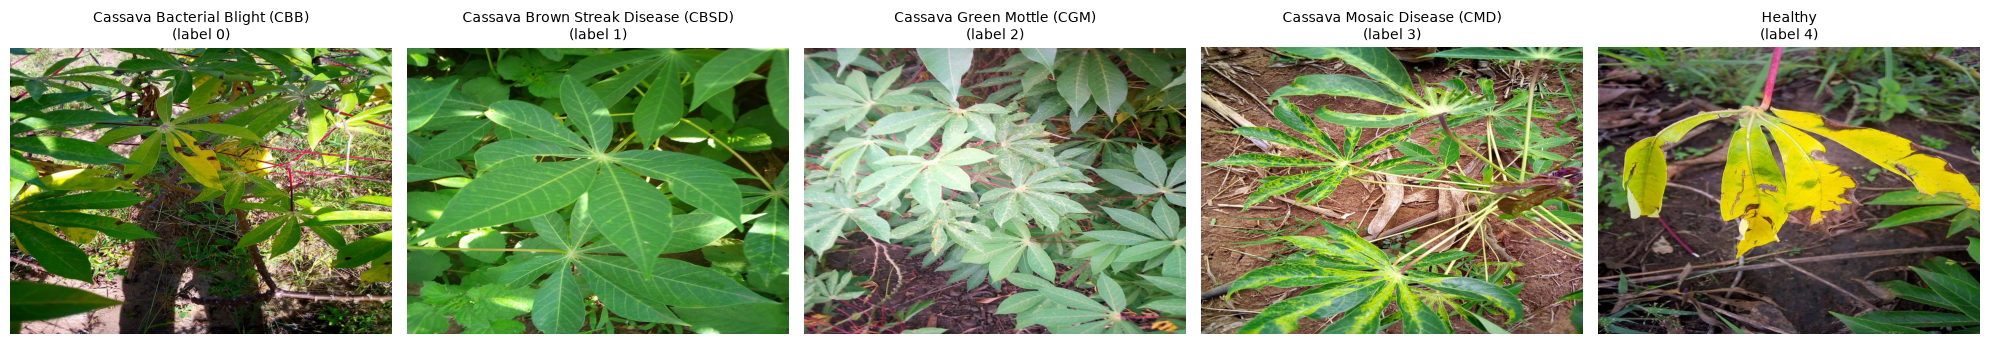

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for label_id in range(5):
    sample_row = train_df[train_df['label'] == label_id].iloc[0]
    img_path = f"../data/train_images/{sample_row['image_id']}"
    img = Image.open(img_path)
    axes[label_id].imshow(img)
    axes[label_id].set_title(f"{sample_row['disease_name']}\n(label {label_id})", fontsize=10)
    axes[label_id].axis('off')

plt.tight_layout()
plt.show()